# How to Win the VN1 Competition

## NeuralForecast

In [3]:
import pandas as pd 
from neuralforecast import NeuralForecast
from utilsforecast.plotting import plot_series
from neuralforecast.models import (
    # Classic Networks
    DilatedRNN,
    # Advanced Architectures
    NBEATS, 
    # Transformer Model
    PatchTST,
    # Modern Architectures
    TiDE
)


In [4]:
# Load prepared data
df = pd.read_parquet("../data_prepared/df.parquet")

### Model Fitting and Forecasting

In [3]:
# Common parameters
h = 13  # Forecast horizon
input_size = 104  # 2 years of weekly data for seasonality
batch_size = 32
learning_rate = 0.001

models = [
    TiDE(
        h=h,
        input_size=input_size,
        scaler_type='robust',
        hidden_size=512,
        decoder_output_dim=16,
        dropout=0.3,
        max_steps=2000,
        batch_size=batch_size,
        learning_rate=learning_rate,
        enable_progress_bar=False
    ),
    # DilatedRNN with extended dilations and LSTM for long-term dependencies
    DilatedRNN(
        h=h,
        input_size=input_size,
        scaler_type='robust',
        encoder_hidden_size=200,
        decoder_hidden_size=200,
        cell_type='LSTM',  # Better for seasonality than GRU
        dilations=[[1, 2, 4], [8, 16, 32]],  # Extended for weekly patterns
        batch_size=batch_size,
        learning_rate=learning_rate,
        enable_progress_bar=False
    ),
    NBEATS(
        h=h,
        input_size=input_size,
        scaler_type='robust',
        stack_types=['trend', 'seasonality'],  # Explicit decomposition
        n_blocks=[4, 4],
        mlp_units=[[512, 512], [512, 512]],
        n_harmonics=2,  # For weekly seasonality
        max_steps=2000,
        batch_size=batch_size,
        learning_rate=learning_rate,
        enable_progress_bar=False
    ),
    PatchTST(
        h=h,
        input_size=input_size,
        scaler_type='robust',
        patch_len=16,
        stride=8,
        hidden_size=256,
        n_heads=16,
        encoder_layers=3,
        dropout=0.2,
        batch_size=batch_size,
        learning_rate=0.0001,
        enable_progress_bar=False
    ),
]


Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1


In [4]:
# Create NeuralForecast object with optimized models
nf = NeuralForecast(
    models=models,
    freq='W-MON',
)

In [5]:
# Fit all models on the cleaned data
nf.fit(df=df)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name             | Type          | Params | Mode  | FLOPs
-------------------------------------------------------------------
0 | loss             | MAE           | 0      | train | 0    
1 | padder_train     | ConstantPad1d | 0      | train | 0    
2 | scaler           | TemporalNorm  | 0      | train | 0    
3 | dense_encoder    | Sequential    | 371 K  | train | 0    
4 | dense_decoder    | Sequential    | 476 K  | train | 0    
5 | temporal_decoder | MLPResidual   | 2.3 K  | train | 0    
6 | global_skip      | Linear        | 1.4 K  | train | 0    
-------------------------------------------------------------------
851 K     Trainable params
0         Non-trainable params
851 K     Total params
3.405     Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode
0         Total Flops
/Users/nasaul/nixtla/modern_forecasting_course/.venv/lib/python3.13/site-

In [ ]:
#fc_nf = nf.predict()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/nasaul/nixtla/modern_forecasting_course/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/nasaul/nixtla/modern_forecasting_course/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


In [6]:
fc_nf = pd.read_parquet('../output/nf_fc.parquet')

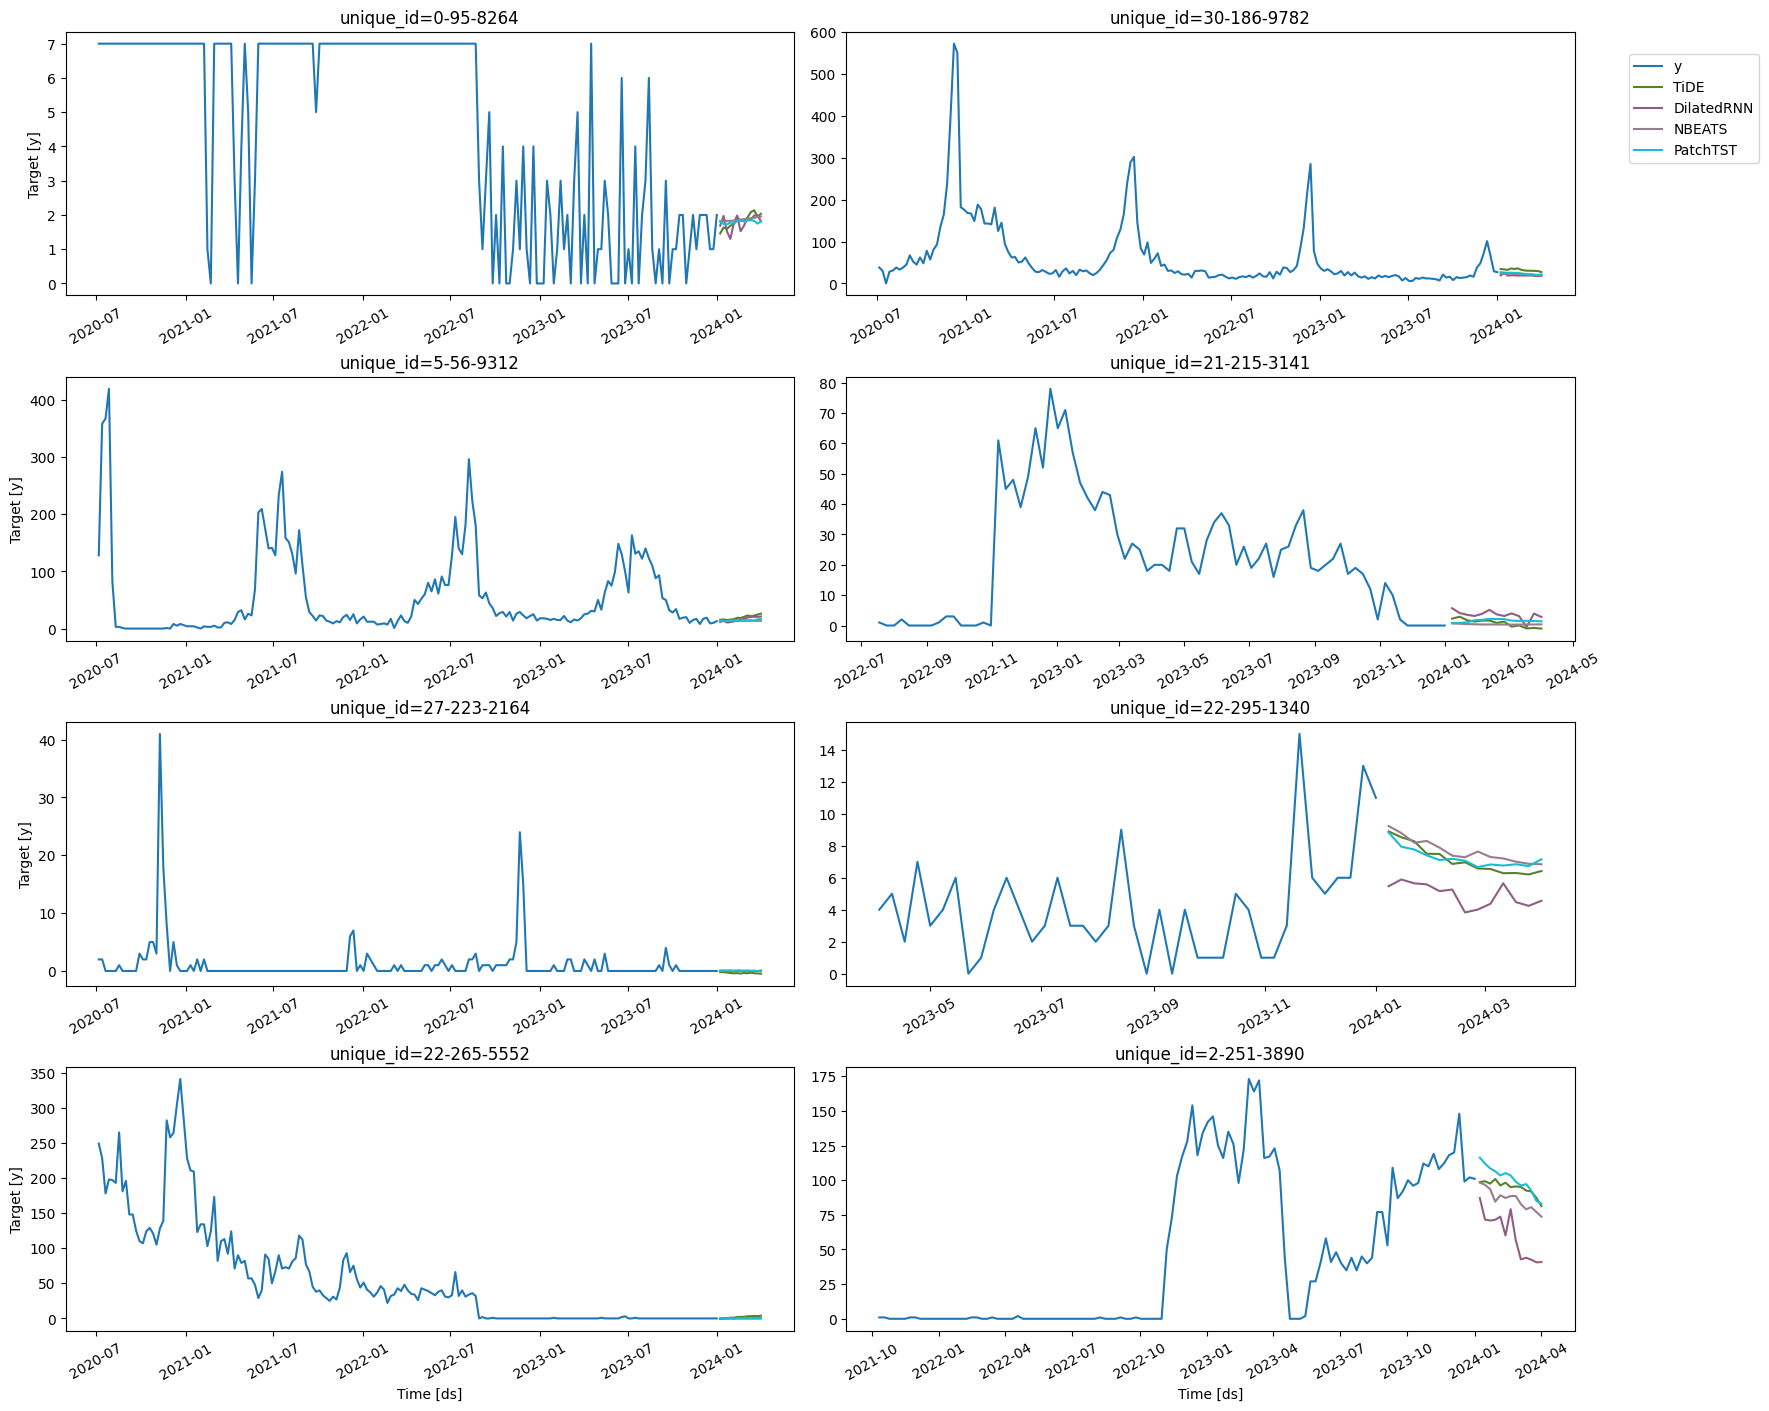

In [7]:
plot_series(df, fc_nf)

In [8]:
from utils import vn1_competition_evaluation

nf_scores = vn1_competition_evaluation(fc_nf)

In [9]:
winners_scores = pd.read_parquet('../scores/winners_scores.parquet')

results = pd.concat([winners_scores, nf_scores])
results.sort_values(by='score')

,model,score
0,1st place,0.46375
1,2nd place,0.46568
2,3rd place,0.47578
3,4th place,0.47743
4,5th place,0.48081
2,NBEATS,0.55490
3,PatchTST,0.55840
0,TiDE,0.56804
1,DilatedRNN,0.63154
